# File Dokumen: Data Cleaning Harga Bahan Pokok.ipynb
file ini berisi tentang data cleaning harga bahan pokok di pasar tradisional di Jakarta, Indonesia. Data ini mencakup informasi tentang harga berbagai bahan pokok seperti beras, minyak goreng, gula, dan lainnya. Tujuan dari data cleaning ini adalah untuk membersihkan dan mempersiapkan data untuk analisis lebih lanjut. Proses data cleaning melibatkan langkah-langkah seperti menghapus duplikasi, menangani nilai yang hilang, memperbaiki format data, dan mengidentifikasi serta menangani outlier. Data yang telah dibersihkan akan lebih akurat dan dapat diandalkan untuk analisis tren harga, perbandingan harga antar pasar, dan prediksi harga di masa depan. Data ini dapat digunakan oleh pedagang, konsumen, dan pembuat kebijakan untuk memahami dinamika harga bahan pokok dan membuat keputusan yang lebih baik.

## Import Dataset

In [2]:
! gdown 121yjSmlwbG73FNlsrWzVc23AtWZ6s1yM

'gdown' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import os
import pandas as pd

path1 = 'dataset/PIHPS_Jakarta_Full_2021_2026.csv'
path2 = 'PIHPS_Jakarta_Full_2021_2026.csv'

if os.path.exists(path1):
    path = path1
elif os.path.exists(path2):
    path = path2
else:
    raise FileNotFoundError("Neither file path exists.")

df_harga = pd.read_csv(path, sep=',')
df_harga.info()

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Tanggal                          1386 non-null   str  
 1   Bawang Merah                     1386 non-null   str  
 2   Bawang Merah Ukuran Sedang       1386 non-null   str  
 3   Bawang Putih                     1386 non-null   str  
 4   Bawang Putih Ukuran Sedang       1386 non-null   str  
 5   Beras                            1386 non-null   str  
 6   Beras Kualitas Bawah I           1386 non-null   str  
 7   Beras Kualitas Bawah II          1386 non-null   str  
 8   Beras Kualitas Medium I          1386 non-null   str  
 9   Beras Kualitas Medium II         1386 non-null   str  
 10  Beras Kualitas Super I           1386 non-null   str  
 11  Beras Kualitas Super II          1386 non-null   str  
 12  Cabai Merah                      1386 non-null   str  
 13 

## Data Cleaning

In [4]:
# ubah format tanggal
df_harga["Tanggal"] = pd.to_datetime(df_harga["Tanggal"], format="%Y-%m-%d")

df_harga.info()

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Tanggal                          1386 non-null   datetime64[us]
 1   Bawang Merah                     1386 non-null   str           
 2   Bawang Merah Ukuran Sedang       1386 non-null   str           
 3   Bawang Putih                     1386 non-null   str           
 4   Bawang Putih Ukuran Sedang       1386 non-null   str           
 5   Beras                            1386 non-null   str           
 6   Beras Kualitas Bawah I           1386 non-null   str           
 7   Beras Kualitas Bawah II          1386 non-null   str           
 8   Beras Kualitas Medium I          1386 non-null   str           
 9   Beras Kualitas Medium II         1386 non-null   str           
 10  Beras Kualitas Super I           1386 non-null   str           
 11  Be

In [5]:
df_harga.head()

,Tanggal,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar
0,2021-01-01,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
1,2021-01-04,"35,000","35,000","35,850","35,850","13,450","12,150","11,300","13,950","12,750",...,"123,350","15,100","15,500","14,650","14,950","14,850","15,000","15,000","25,650","25,650"
2,2021-01-05,"35,000","35,000","35,850","35,850","13,450","12,150","11,300","13,950","12,750",...,"123,350","15,100","15,500","14,650","14,950","14,850","15,000","15,000","25,650","25,650"
3,2021-01-06,"33,350","33,350","35,850","35,850","13,450","12,150","11,300","13,950","12,750",...,"123,350","15,100","15,500","14,650","14,950","14,850","15,000","15,000","25,500","25,500"
4,2021-01-07,"33,350","33,350","35,850","35,850","13,450","12,150","11,300","13,950","12,750",...,"122,500","15,000","15,350","14,650","14,950","14,850","15,000","15,000","25,350","25,350"


In [6]:
# Ubah kolom harga dari string ke numeric
harga_columns = df_harga.columns[1:]  # Asumsikan kolom pertama adalah 'Tanggal'
for col in harga_columns:
    df_harga[col] = df_harga[col].str.replace(',', '', regex=False)  # Hapus koma sebagai pemisah ribuan
    df_harga[col] = pd.to_numeric(df_harga[col], errors='coerce')  # Ubah ke numeric, non-numeric akan menjadi NaN
df_harga.info()

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Tanggal                          1386 non-null   datetime64[us]
 1   Bawang Merah                     1350 non-null   float64       
 2   Bawang Merah Ukuran Sedang       1351 non-null   float64       
 3   Bawang Putih                     1350 non-null   float64       
 4   Bawang Putih Ukuran Sedang       1351 non-null   float64       
 5   Beras                            1350 non-null   float64       
 6   Beras Kualitas Bawah I           1351 non-null   float64       
 7   Beras Kualitas Bawah II          1351 non-null   float64       
 8   Beras Kualitas Medium I          1351 non-null   float64       
 9   Beras Kualitas Medium II         1351 non-null   float64       
 10  Beras Kualitas Super I           1351 non-null   float64       
 11  Be

In [7]:
df_harga.head()

,Tanggal,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar
0,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-04,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
2,2021-01-05,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
3,2021-01-06,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25500.0,25500.0
4,2021-01-07,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,122500.0,15000.0,15350.0,14650.0,14950.0,14850.0,15000.0,15000.0,25350.0,25350.0


## Cek Missing Values

In [8]:
# Periksa nilai yang hilang
df_harga.isna().sum()

Tanggal                             0
Bawang Merah                       36
Bawang Merah Ukuran Sedang         35
Bawang Putih                       36
Bawang Putih Ukuran Sedang         35
Beras                              36
Beras Kualitas Bawah I             35
Beras Kualitas Bawah II            35
Beras Kualitas Medium I            35
Beras Kualitas Medium II           35
Beras Kualitas Super I             35
Beras Kualitas Super II            35
Cabai Merah                        36
Cabai Merah Besar                  35
Cabai Merah Keriting               35
Cabai Rawit                        36
Cabai Rawit Hijau                  35
Cabai Rawit Merah                  35
Daging Ayam                        36
Daging Ayam Ras Segar              35
Daging Sapi                        36
Daging Sapi Kualitas 1             35
Daging Sapi Kualitas 2             35
Gula Pasir                         36
Gula Pasir Kualitas Premium        35
Gula Pasir Lokal                   35
Minyak Goren

In [9]:
# Cek baris kosong penuh / parsial
df_harga[df_harga.isna().any(axis=1)]

,Tanggal,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar
0,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,2021-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,2021-03-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,2021-04-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,2021-05-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,2021-05-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,2021-05-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,2021-05-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,2021-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142,2021-07-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# cek baris duplikat
df_harga[df_harga.duplicated()]

,Tanggal,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar


## Set Index dan Urutkan Data

In [11]:
# Set index ke kolom Tanggal dan urutkan berdasarkan tanggal lama ke baru

harga_time = df_harga.set_index("Tanggal")
harga_time = harga_time.sort_index()
harga_time.head()

,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar
Tanggal,,,,,,,,,,,,,,,,,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
2021-01-05,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
2021-01-06,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25500.0,25500.0
2021-01-07,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,122500.0,15000.0,15350.0,14650.0,14950.0,14850.0,15000.0,15000.0,25350.0,25350.0


## Handle Missing Values dengan Interpolasi Linier

In [12]:
# Lakukan interpolasi linier pada semua kolom
df_harga = df_harga.interpolate(method='linear')
# Periksa kembali nilai yang hilang setelah interpolasi
df_harga.isna().sum()

Tanggal                            0
Bawang Merah                       1
Bawang Merah Ukuran Sedang         1
Bawang Putih                       1
Bawang Putih Ukuran Sedang         1
Beras                              1
Beras Kualitas Bawah I             1
Beras Kualitas Bawah II            1
Beras Kualitas Medium I            1
Beras Kualitas Medium II           1
Beras Kualitas Super I             1
Beras Kualitas Super II            1
Cabai Merah                        1
Cabai Merah Besar                  1
Cabai Merah Keriting               1
Cabai Rawit                        1
Cabai Rawit Hijau                  1
Cabai Rawit Merah                  1
Daging Ayam                        1
Daging Ayam Ras Segar              1
Daging Sapi                        1
Daging Sapi Kualitas 1             1
Daging Sapi Kualitas 2             1
Gula Pasir                         1
Gula Pasir Kualitas Premium        1
Gula Pasir Lokal                   1
Minyak Goreng                      1
M

In [13]:
# lihat baris ke 30 setelah interpolasi
df_harga.iloc[29:32]

,Tanggal,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar
29,2021-02-11,40850.0,40850.0,37150.0,37150.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,122500.0,14750.0,15150.0,14350.0,14900.0,14650.0,15000.0,15000.0,24650.0,24650.0
30,2021-02-12,41250.0,41250.0,36500.0,36500.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,122500.0,14750.0,15150.0,14350.0,14900.0,14650.0,15000.0,15000.0,24825.0,24825.0
31,2021-02-15,41650.0,41650.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,122500.0,14750.0,15150.0,14350.0,14900.0,14650.0,15000.0,15000.0,25000.0,25000.0


## Save Cleaned Data

In [14]:
# save data yang sudah dibersihkan ke file baru
harga_time.to_csv('dataset/PIHPS_Jakarta_Cleaned_2021_2026.csv', index=True)

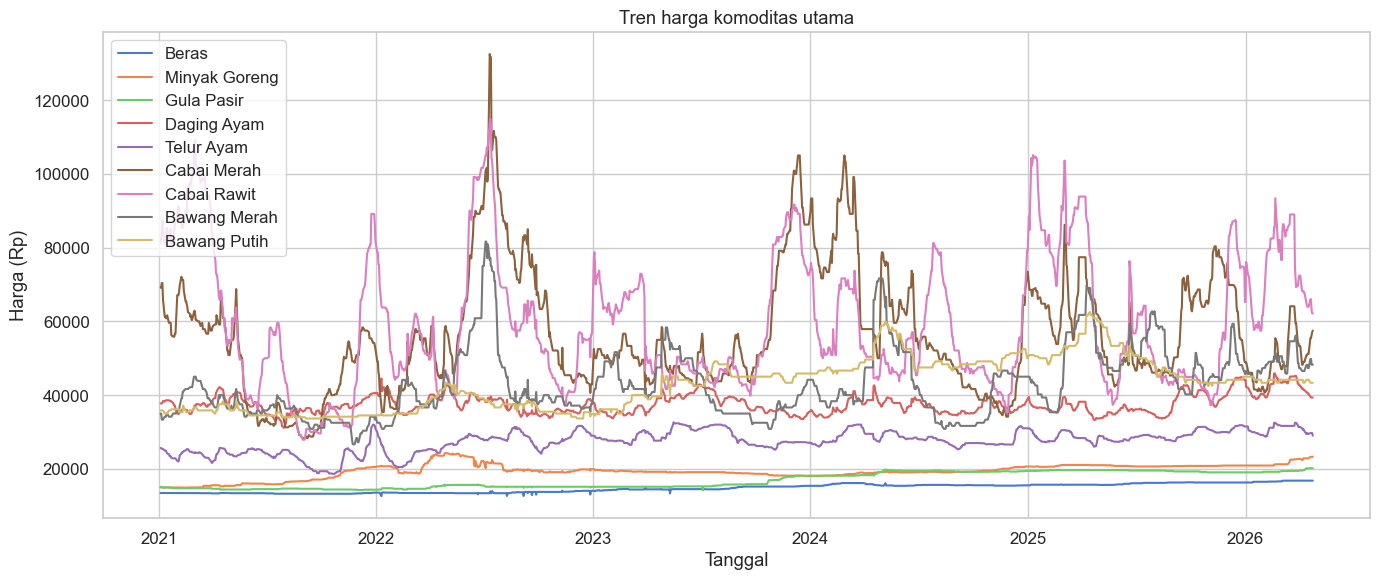

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Siapkan data numerik dan time series
harga_numeric = df_harga.select_dtypes(include=[np.number])
harga_time = df_harga.set_index("Tanggal")[harga_numeric.columns]

# Visualisasi tren harga beberapa komoditas utama
selected = [
    "Beras",
    "Minyak Goreng",
    "Gula Pasir",
    "Daging Ayam",
    "Telur Ayam",
    "Cabai Merah",
    "Cabai Rawit",
    "Bawang Merah",
    "Bawang Putih",
    "Daging Sapi "
]
selected = [c for c in selected if c in harga_time.columns]
plt.figure(figsize=(14, 6))
for col in selected:
    plt.plot(harga_time.index, harga_time[col], label=col)

plt.legend(loc="upper left")
plt.title("Tren harga komoditas utama")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.tight_layout()
plt.show()